# Scope Data Blueprint (Polars)

Ce notebook synthétise les besoins "Scope & Données" partagés (Retailers, Publishers, segments Hill's, Clean Room) à partir des fichiers `input_data/X_2025`. L'objectif est double :

- **Cartographier** les jeux de données disponibles pour chacun des blocs demandés (SKU/prix, expositions média, segments CRM, jointures anonymisées, etc.).
- **Produire des KPI prêts à l'emploi** et des structures de données réutilisables (Polars) pour alimenter des analyses métier ou des exports vers un clean room.

> **Technologie** : toutes les manipulations sont effectuées en Polars (lazy evaluation) pour rester aligné avec la stratégie de performance du projet.


## 0. Périmètre attendu

| Bloc | Besoins métier | Sources utilisées |
| --- | --- | --- |
| **Retailers** | Transactions, SKU, prix, historique client, fréquence/panier, ruptures & stock | `retailer.csv` |
| **Publishers** | Impressions/clicks, ordre d'exposition par ID, interactions (watchtime/CTR), données socio-démo | `tv_publisher.csv`, `programmatic_publisher.csv`, `mapping_transac_publisher_tv.csv`, `socio_demo.csv` |
| **Hill's / CRM** | Segments CRM, mix produits (Prescription Diet, Science Diet, …), feedback clients | `retailer.csv`, `socio_demo.csv` |
| **Clean Room** | Jointure anonymisée Retail × Publisher × Hill's, séquences d'exposition, lift incrémental (closed-loop) | Ensemble des fichiers via Polars + mapping |

Chaque section ci-dessous construit les structures de données nécessaires et documente les éventuels manques (ex. absence de colonnes `stock_level`, `clicks`, `watch_time`).


In [2]:
# Imports & configuration
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(12)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("deep")

DATA_PATH = Path("input_data") / "X_2025"
print(f"Données chargées depuis: {DATA_PATH.resolve()}")


Données chargées depuis: /home/nathan/Documents/data_challenge_mie/input_data/X_2025


In [3]:
# Chargement lazy des datasets (on force les dates à rester en String)
sc_retailer = pl.scan_csv(DATA_PATH / "retailer.csv")
sc_tv = pl.scan_csv(DATA_PATH / "tv_publisher.csv")
sc_prog = pl.scan_csv(DATA_PATH / "programmatic_publisher.csv")
sc_mapping = pl.scan_csv(DATA_PATH / "mapping_transac_publisher_tv.csv")
sc_socio = pl.scan_csv(DATA_PATH / "socio_demo.csv")

datasets = {
    "Retailer": sc_retailer,
    "TV": sc_tv,
    "Programmatic": sc_prog,
    "Mapping": sc_mapping,
    "SocioDemo": sc_socio,
}

for name, lf in datasets.items():
    print("\n" + "-" * 80)
    print(f"{name} → colonnes: {list(lf.schema.keys())}")
    sample = lf.head(3).collect()
    print(sample)
print("\nLazyFrames prêts pour les jointures Polars.")



--------------------------------------------------------------------------------
Retailer → colonnes: ['customer_id', 'timestamp_utc', 'event_name', 'brand', 'product_name', 'sales', 'quantity']
shape: (3, 7)
┌────────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────┬──────────┐
│ customer_id    ┆ timestamp_utc ┆ event_name    ┆ brand        ┆ product_name  ┆ sales ┆ quantity │
│ ---            ┆ ---           ┆ ---           ┆ ---          ┆ ---           ┆ ---   ┆ ---      │
│ str            ┆ str           ┆ str           ┆ str          ┆ str           ┆ f64   ┆ f64      │
╞════════════════╪═══════════════╪═══════════════╪══════════════╪═══════════════╪═══════╪══════════╡
│ reFs5GI87lXJkJ ┆ 2024-02-07    ┆ Product Page  ┆ null         ┆ null          ┆ null  ┆ null     │
│ Si9r           ┆ 02:27:10      ┆ View          ┆              ┆               ┆       ┆          │
│ reFs5GI87lXJkJ ┆ 2024-06-12    ┆ Product Page  ┆ Science Diet ┆ SD Fel A7+    ┆ n

/tmp/ipykernel_7958/1122510760.py:18: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(f"{name} → colonnes: {list(lf.schema.keys())}")


shape: (3, 5)
┌────────────────────────────┬─────────────────────┬───────────────┬─────────────┬─────────────────┐
│ dsp_id                     ┆ timestamp_utc       ┆ campaign_name ┆ device_type ┆ cost_milli_cent │
│ ---                        ┆ ---                 ┆ ---           ┆ ---         ┆ ---             │
│ str                        ┆ str                 ┆ str           ┆ str         ┆ f64             │
╞════════════════════════════╪═════════════════════╪═══════════════╪═════════════╪═════════════════╡
│ dsp9tnGII5BeXbn6LUSFZPcKGC ┆ 2024-02-06 04:10:41 ┆ Contextual    ┆ Phone       ┆ 283.496         │
│ yI0F                       ┆                     ┆               ┆             ┆                 │
│ dsp1hXcI9Q6TZYzLEmeTkxzhjq ┆ 2024-02-26 23:49:23 ┆ Retargeting   ┆ PC          ┆ 1884.537        │
│ D6HJ                       ┆                     ┆               ┆             ┆                 │
│ dspcd3UcXUcUk0PEo2hb8CEH3W ┆ 2024-06-16 20:55:27 ┆ Contextual    ┆ TV      

### Normalisation & filtrage des identifiants

Avant toute agrégation, on nettoie tous les identifiants (`customer_id`, `device_id`, `dsp_id`) en supprimant les espaces et en excluant les valeurs vides/`unknown`. Ceci garantit que les tableaux Retailers/Publishers/Hill's ne contiennent que des individus adressables dans le clean room.


In [4]:
INVALID_ID_TOKENS = ("", "unknown", "unk", "na", "null", "none")

def clean_id(col_name: str, alias: str | None = None) -> pl.Expr:
    cleaned = pl.col(col_name).cast(pl.Utf8, strict=False).str.strip_chars()
    return cleaned.alias(alias or col_name)

def valid_id(col_name: str) -> pl.Expr:
    cleaned = pl.col(col_name).cast(pl.Utf8, strict=False).str.strip_chars()
    lowered = cleaned.str.to_lowercase()
    return (
        cleaned.is_not_null()
        & (cleaned.str.len_chars() > 0)
        & (~lowered.is_in(INVALID_ID_TOKENS))
    )

sc_retailer = (
    sc_retailer
    .with_columns([clean_id("customer_id")])
    .filter(valid_id("customer_id"))
)

sc_mapping = (
    sc_mapping
    .with_columns([
        clean_id("customer_id"),
        clean_id("device_id"),
        clean_id("dsp_id"),
    ])
    .filter(valid_id("customer_id"))
)

sc_socio = (
    sc_socio
    .with_columns([clean_id("customer_id")])
    .filter(valid_id("customer_id"))
)

sc_tv = (
    sc_tv
    .with_columns([clean_id("device_id")])
    .filter(valid_id("device_id"))
)

sc_prog = (
    sc_prog
    .with_columns([clean_id("dsp_id")])
    .filter(valid_id("dsp_id"))
)

print("✓ Identifiants normalisés et lignes 'unknown' exclues")


✓ Identifiants normalisés et lignes 'unknown' exclues


## 1. Données Retailers (Transactions / SKU / Prix / Historique)

Objectifs :
- **Transactions & paniers** : volume, panier moyen, fréquence d'achat par client.
- **SKU & prix** : couverture assortiment, prix moyen par produit.
- **Historique & fréquence** : timeline hebdomadaire/mois + récurrence clients.
- **Ruptures & stock** : identification des transactions avec `quantity ≤ 0` comme proxy d'anomalie (le dataset ne contient pas de colonnes explicites `stock_level`).


In [5]:
# Préparation Retailer (parse → cache eager → réutilisation lazy)
retailer_base = (
    sc_retailer
    .with_columns([
        pl.col("timestamp_utc").str.strptime(pl.Datetime, strict=False, format=None).alias("ts"),
        pl.col("sales").fill_null(0),
        pl.col("quantity").fill_null(0),
    ])
    .with_columns([
        pl.col("ts").dt.date().alias("order_date"),
        pl.col("ts").dt.truncate("1w").alias("week_start"),
        pl.col("ts").dt.truncate("1mo").alias("month_start"),
        pl.when(pl.col("quantity") <= 0)
          .then(None)
          .otherwise(pl.col("sales") / pl.col("quantity"))
          .alias("unit_price"),
    ])
)

retailer = retailer_base.collect(streaming=True)
retailer_lazy = retailer.lazy()

retailer_kpis = (
    retailer_lazy
    .select([
        pl.len().alias("transactions"),
        pl.col("customer_id").n_unique().alias("unique_customers"),
        pl.col("product_name").n_unique().alias("unique_skus"),
        pl.col("sales").sum().alias("total_sales"),
        pl.col("sales").mean().alias("avg_basket"),
        (pl.col("sales").sum() / pl.col("quantity").sum()).alias("avg_unit_price"),
        pl.col("quantity").mean().alias("avg_units_per_tx"),
    ])
    .collect()
)

customer_lifecycle = (
    retailer_lazy
    .group_by("customer_id")
    .agg([
        pl.len().alias("transactions"),
        pl.col("sales").sum().alias("sales"),
        pl.col("ts").min().alias("first_purchase"),
        pl.col("ts").max().alias("last_purchase"),
    ])
    .with_columns([
        (pl.col("last_purchase") - pl.col("first_purchase")).dt.total_days().alias("lifetime_days"),
    ])
)

customer_stats = (
    customer_lifecycle
    .select([
        pl.len().alias("customers"),
        pl.col("transactions").mean().alias("avg_tx_per_customer"),
        pl.col("sales").mean().alias("avg_customer_value"),
        pl.col("lifetime_days").mean().alias("avg_lifetime_days"),
        pl.col("lifetime_days").median().alias("median_lifetime_days"),
    ])
    .collect()
)

weekly_history = (
    retailer_lazy
    .group_by("week_start")
    .agg([
        pl.col("sales").sum().alias("revenue"),
        pl.len().alias("transactions"),
        pl.col("customer_id").n_unique().alias("active_customers"),
    ])
    .sort("week_start")
    .collect()
)

sku_pricing = (
    retailer_lazy
    .group_by("product_name")
    .agg([
        pl.col("sales").sum().alias("revenue"),
        pl.col("quantity").sum().alias("units"),
        pl.col("unit_price").mean().alias("avg_unit_price"),
    ])
    .sort("revenue", descending=True)
    .head(25)
    .collect()
)

stock_alerts = (
    retailer_lazy
    .filter(pl.col("quantity") <= 0)
    .group_by("product_name")
    .agg([
        pl.len().alias("anomaly_tx"),
        pl.col("sales").sum().alias("sales_flagged"),
    ])
    .sort("anomaly_tx", descending=True)
    .collect()
)

print("KPIs Retailer :")
print(retailer_kpis)
print("\nStats clients :")
print(customer_stats)
print("\nHistorique hebdomadaire (aperçu) :")
print(weekly_history.head(12))
print("\nTop 25 SKU / prix moyen :")
print(sku_pricing)
print("\nTransactions suspectes (quantity ≤ 0) → proxy ruptures/retours :")
print(stock_alerts)


/tmp/ipykernel_7958/3321825689.py:20: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  retailer = retailer_base.collect(streaming=True)


KPIs Retailer :
shape: (1, 7)
┌──────────────┬──────────────┬─────────────┬─────────────┬────────────┬─────────────┬─────────────┐
│ transactions ┆ unique_custo ┆ unique_skus ┆ total_sales ┆ avg_basket ┆ avg_unit_pr ┆ avg_units_p │
│ ---          ┆ mers         ┆ ---         ┆ ---         ┆ ---        ┆ ice         ┆ er_tx       │
│ u32          ┆ ---          ┆ u32         ┆ f64         ┆ f64        ┆ ---         ┆ ---         │
│              ┆ u32          ┆             ┆             ┆            ┆ f64         ┆ f64         │
╞══════════════╪══════════════╪═════════════╪═════════════╪════════════╪═════════════╪═════════════╡
│ 9671519      ┆ 1354583      ┆ 506         ┆ 6.1193e7    ┆ 6.327184   ┆ 40.12482    ┆ 0.157688    │
└──────────────┴──────────────┴─────────────┴─────────────┴────────────┴─────────────┴─────────────┘

Stats clients :
shape: (1, 5)
┌───────────┬─────────────────────┬────────────────────┬───────────────────┬──────────────────────┐
│ customers ┆ avg_tx_per_custom

### Visualisations Retailers

Les graphiques ci-dessous répondent aux besoins KPIs (fréquence/panier, dynamique SKU, ruptures) en utilisant Matplotlib depuis les agrégations Polars ci-dessus.


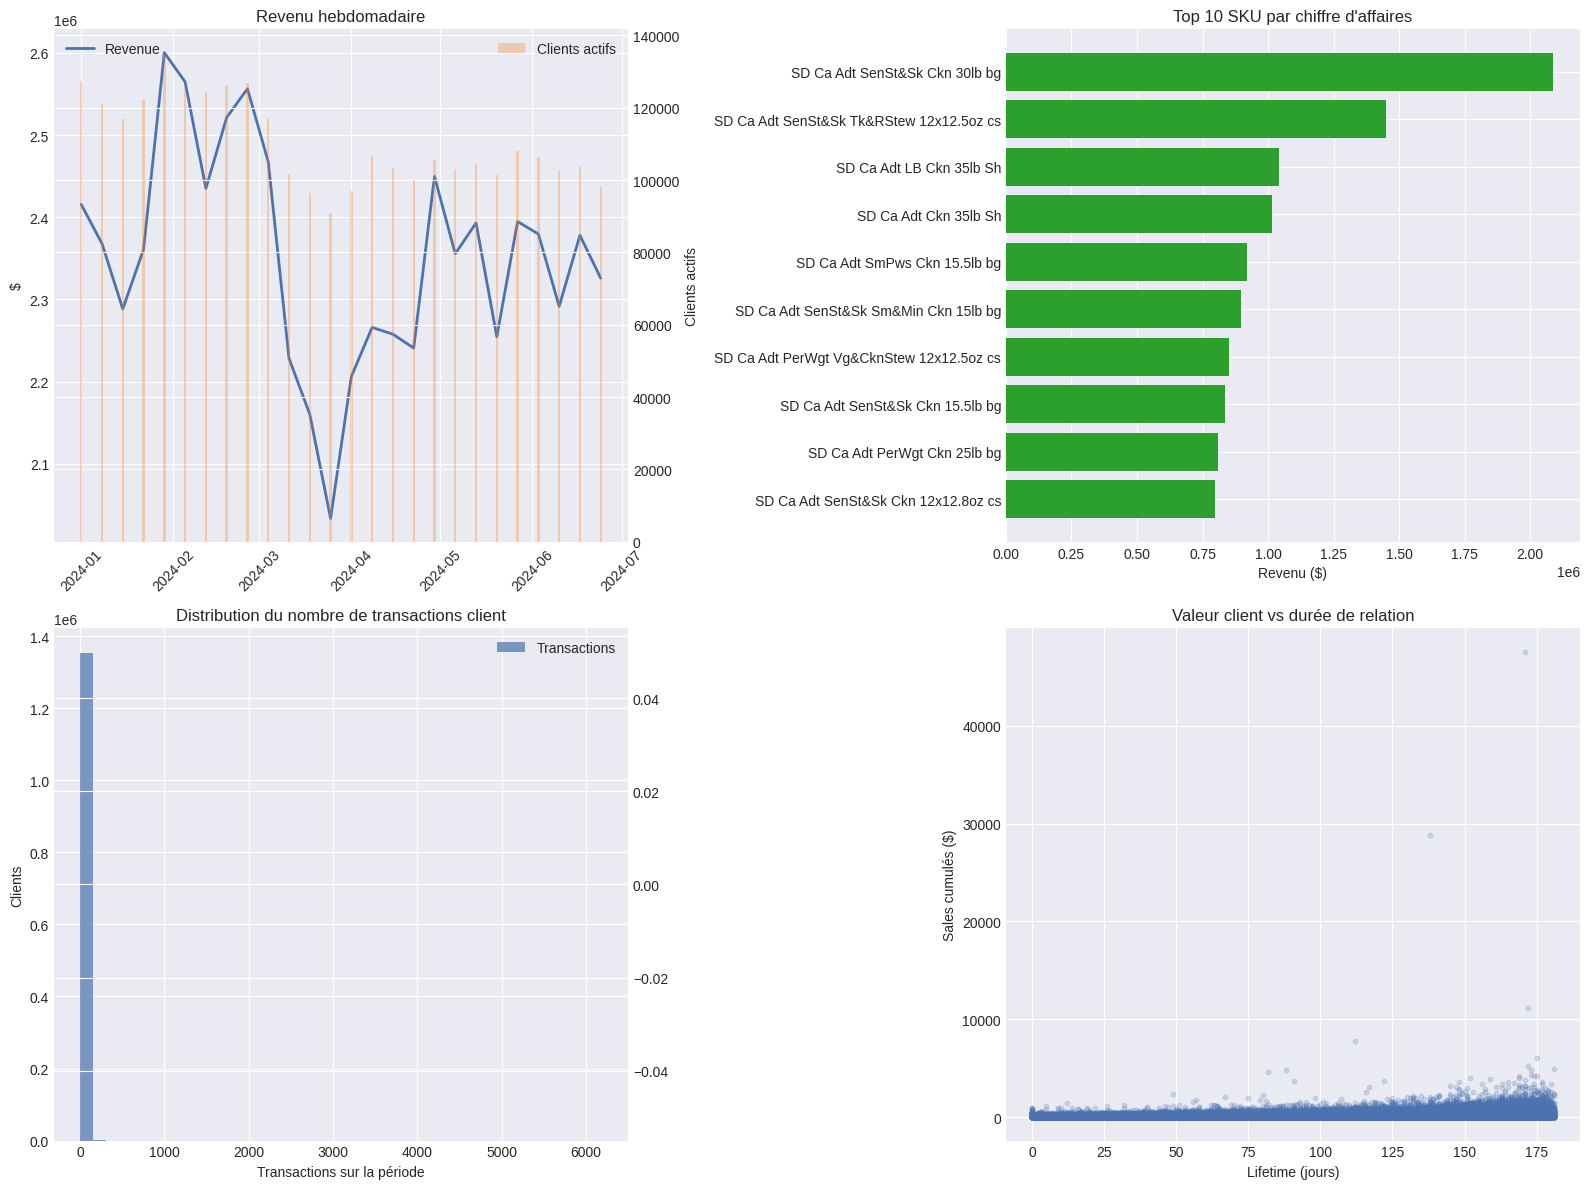

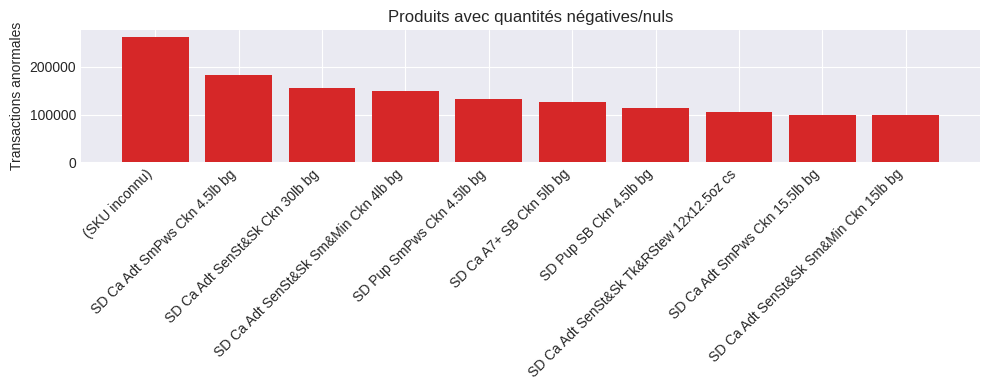

In [6]:
# Graphiques Retailers
weekly_pd = weekly_history.to_pandas()
sku_pd = sku_pricing.head(10).to_pandas()
stock_pd = stock_alerts.to_pandas().head(10)
customer_pd = (
    customer_lifecycle
    .select([
        pl.col("transactions"),
        pl.col("sales"),
        pl.col("lifetime_days"),
    ])
    .collect()
    .to_pandas()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Revenue & clients actifs (hebdo)
ax1 = axes[0, 0]
ax1.plot(weekly_pd["week_start"], weekly_pd["revenue"], label="Revenue", linewidth=2)
ax1.set_title("Revenu hebdomadaire")
ax1.set_ylabel("$")
ax2 = ax1.twinx()
ax2.bar(weekly_pd["week_start"], weekly_pd["active_customers"], alpha=0.3, color="tab:orange", label="Clients actifs")
ax2.set_ylabel("Clients actifs")
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# 2. Top SKU (CA)
axes[0, 1].barh(sku_pd["product_name"], sku_pd["revenue"], color="tab:green")
axes[0, 1].invert_yaxis()
axes[0, 1].set_title("Top 10 SKU par chiffre d'affaires")
axes[0, 1].set_xlabel("Revenu ($)")

# 3. Distribution transactions / lifetime
axes[1, 0].hist(customer_pd["transactions"], bins=40, alpha=0.7, label="Transactions")
axes[1, 0].set_title("Distribution du nombre de transactions client")
axes[1, 0].set_xlabel("Transactions sur la période")
axes[1, 0].set_ylabel("Clients")
axes[1, 0].legend()

a3 = axes[1, 0].twinx()
a3.plot([], [])  # placeholder to keep layout

# Lifetime scatter vs sales
axes[1, 1].scatter(customer_pd["lifetime_days"], customer_pd["sales"], alpha=0.2, s=10)
axes[1, 1].set_title("Valeur client vs durée de relation")
axes[1, 1].set_xlabel("Lifetime (jours)")
axes[1, 1].set_ylabel("Sales cumulés ($)")

plt.tight_layout()
plt.show()

# Alertes stock / anomalies
if len(stock_pd) > 0:
    safe_labels = stock_pd["product_name"].fillna("(SKU inconnu)")
    plt.figure(figsize=(10, 4))
    plt.bar(safe_labels, stock_pd["anomaly_tx"], color="tab:red")
    plt.xticks(rotation=45, ha='right')
    plt.title("Produits avec quantités négatives/nuls")
    plt.ylabel("Transactions anormales")
    plt.tight_layout()
    plt.show()
else:
    print("Aucune anomalie de stock détectée.")


### Visualisations Publishers & Clean Room

Les graphiques suivants couvrent l'exposition média (volume/impressions, CPM, séquences) et la préparation Clean Room (jointure clients × canaux × segments socio-démo).


In [7]:
# Graphiques Publishers

def _ensure_publisher_frames():
    required = ["publisher_events", "publisher_kpis", "publisher_socio", "publisher_gaps"]
    if all(name in globals() for name in required):
        return

    mapping_devices = (
        sc_mapping.select(["customer_id", "device_id"])
        .filter(pl.col("device_id").is_not_null())
        .filter(valid_id("device_id", allow_unknown=True))
    )
    mapping_dsp = (
        sc_mapping.select(["customer_id", "dsp_id"])
        .filter(pl.col("dsp_id").is_not_null())
        .filter(valid_id("dsp_id", allow_unknown=True))
    )

    tv_events_local = (
        sc_tv
        .with_columns([
            pl.col("timestamp_utc").str.strptime(pl.Datetime, strict=False).alias("timestamp"),
            (pl.col("cost_milli_cent") / 100000).alias("spend_usd"),
            pl.lit("TV").alias("device_type"),
        ])
        .join(mapping_devices, on="device_id", how="inner")
        .select([
            pl.col("customer_id"),
            pl.col("device_id").alias("touchpoint_id"),
            pl.col("timestamp"),
            pl.col("spend_usd"),
            pl.lit("TV").alias("channel"),
            pl.col("device_type"),
        ])
    )

    prog_events_local = (
        sc_prog
        .with_columns([
            pl.col("timestamp_utc").str.strptime(pl.Datetime, strict=False).alias("timestamp"),
            (pl.col("cost_milli_cent") / 100000).alias("spend_usd"),
            pl.coalesce([
                pl.col("device_type"),
                pl.lit("Unknown device"),
            ]).alias("device_type"),
        ])
        .join(mapping_dsp, on="dsp_id", how="inner")
        .select([
            pl.col("customer_id"),
            pl.col("dsp_id").alias("touchpoint_id"),
            pl.col("timestamp"),
            pl.col("spend_usd"),
            pl.lit("Programmatic").alias("channel"),
            pl.col("device_type"),
        ])
    )

    publisher_events_local = pl.concat([tv_events_local, prog_events_local], how="vertical")

    publisher_kpis_local = (
        publisher_events_local
        .group_by("channel")
        .agg([
            pl.len().alias("impressions"),
            pl.col("customer_id").n_unique().alias("unique_customers"),
            pl.col("spend_usd").sum().alias("spend_usd"),
            (pl.col("spend_usd").sum() / pl.len() * 1000).alias("cpm"),
        ])
        .collect()
    )

    publisher_socio_local = (
        publisher_events_local
        .join(sc_socio, on="customer_id", how="left")
        .group_by(["channel", "age", "income"])
        .agg([
            pl.col("customer_id").n_unique().alias("unique_customers"),
            pl.len().alias("impressions"),
        ])
        .sort("impressions", descending=True)
        .head(20)
        .collect()
    )

    publisher_device_socio_local = (
        publisher_events_local
        .filter(pl.col("channel") == "Programmatic")
        .join(sc_socio, on="customer_id", how="left")
        .group_by(["device_type", "age", "income"])
        .agg([
            pl.col("customer_id").n_unique().alias("unique_customers"),
            pl.len().alias("impressions"),
        ])
        .sort("impressions", descending=True)
        .collect()
    )

    first_touch_local = (
        publisher_events_local
        .sort(["customer_id", "timestamp"])
        .group_by("customer_id")
        .agg(pl.col("channel").first().alias("first_channel"))
        .group_by("first_channel")
        .agg(pl.len().alias("customers"))
        .collect()
    )
    first_touch_local = first_touch_local.with_columns(
        (pl.col("customers") / pl.col("customers").sum()).alias("share")
    )

    publisher_gaps_local = pl.DataFrame({
        "metric": ["clicks", "watch_time"],
        "status": ["missing", "missing"],
        "comment": [
            "Aucune colonne de clics fournie → prévoir pixel ou log ad-server.",
            "Pas de données watch_time → nécessaire pour la vidéo.",
        ],
    })

    globals().update({
        "publisher_events": publisher_events_local,
        "publisher_kpis": publisher_kpis_local,
        "publisher_socio": publisher_socio_local,
        "publisher_device_socio": publisher_device_socio_local,
        "publisher_gaps": publisher_gaps_local,
        "publisher_first_touch": first_touch_local,
    })

_ensure_publisher_frames()

publisher_events = globals().get("publisher_events")
publisher_kpis = globals().get("publisher_kpis")
publisher_socio = globals().get("publisher_socio")
publisher_device_socio = globals().get("publisher_device_socio")
publisher_gaps = globals().get("publisher_gaps")
publisher_first_touch = globals().get("publisher_first_touch")

if publisher_events is None:
    _ensure_publisher_frames()
    publisher_events = globals()["publisher_events"]
    publisher_kpis = globals()["publisher_kpis"]
    publisher_socio = globals()["publisher_socio"]
    publisher_device_socio = globals()["publisher_device_socio"]
    publisher_gaps = globals()["publisher_gaps"]
    publisher_first_touch = globals().get("publisher_first_touch")

publisher_kpis_pd = publisher_kpis.to_pandas()

publisher_daily = (
    publisher_events
    .with_columns(pl.col("timestamp").dt.date().alias("date"))
    .group_by(["date", "channel"])
    .agg([
        pl.len().alias("impressions"),
        pl.col("spend_usd").sum().alias("spend_usd"),
    ])
    .sort("date")
    .collect()
    .to_pandas()
)

publisher_socio_pd = publisher_socio.to_pandas()
publisher_device_socio_pd = publisher_device_socio.to_pandas() if publisher_device_socio is not None else pd.DataFrame()
publisher_first_touch_pd = publisher_first_touch.to_pandas() if publisher_first_touch is not None else None

sequence_lengths = (
    publisher_events
    .group_by("customer_id")
    .agg(pl.len().alias("touchpoints"))
    .group_by("touchpoints")
    .agg(pl.len().alias("customers"))
    .sort("touchpoints")
    .collect()
    .to_pandas()
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Spend vs impressions par canal
axes[0, 0].bar(publisher_kpis_pd["channel"], publisher_kpis_pd["spend_usd"], color="tab:purple", label="Investissement ($)")
axes[0, 0].set_ylabel("Spend ($)")
axes[0, 0].set_title("Poids des canaux : investissement vs impressions")
ax_imp = axes[0, 0].twinx()
ax_imp.plot(publisher_kpis_pd["channel"], publisher_kpis_pd["impressions"], color="tab:green", marker="o", label="Impressions")
ax_imp.set_ylabel("Impressions")
axes[0, 0].legend(loc="upper left")
ax_imp.legend(loc="upper right")

# 2. Timeline dépenses quotidiennes
for channel, grp in publisher_daily.groupby("channel"):
    axes[0, 1].plot(grp["date"], grp["spend_usd"], label=channel)
axes[0, 1].set_title("Dépenses quotidiennes par canal")
axes[0, 1].set_ylabel("Spend ($)")
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend(title="Canal")
axes[0, 1].grid(alpha=0.2)

# 3. Heatmap socio-démo agrégée
if not publisher_socio_pd.empty:
    demo_pivot = publisher_socio_pd.pivot_table(
        index="income",
        columns="age",
        values="impressions",
        aggfunc="sum",
        fill_value=0
    )
    sns.heatmap(demo_pivot, ax=axes[1, 0], cmap="YlGnBu")
    axes[1, 0].set_title("Impressions (TV + Programmatic) par segment socio-démo")
    axes[1, 0].set_xlabel("Age")
    axes[1, 0].set_ylabel("Income")
else:
    axes[1, 0].text(0.5, 0.5, "Pas de données socio-démo", ha='center')
    axes[1, 0].axis('off')

# 4. Longueur des séquences d'exposition
axes[1, 1].bar(sequence_lengths["touchpoints"], sequence_lengths["customers"], color="tab:orange")
axes[1, 1].set_title("Clients par longueur de séquence (toutes expositions)")
axes[1, 1].set_xlabel("Touchpoints cumulés")
axes[1, 1].set_ylabel("Clients")
axes[1, 1].set_xticks(sequence_lengths["touchpoints"])

plt.tight_layout()
plt.show()

# Heatmaps séparées par canal
channels = ["TV", "Programmatic"]
fig2, axes2 = plt.subplots(1, len(channels), figsize=(14, 5))
for ax, channel in zip(axes2, channels):
    subset = publisher_socio_pd[publisher_socio_pd["channel"] == channel]
    if subset.empty:
        ax.text(0.5, 0.5, f"Pas de données {channel}", ha='center')
        ax.axis('off')
        continue
    pivot = subset.pivot_table(index="income", columns="age", values="impressions", aggfunc="sum", fill_value=0)
    if pivot.size == 0:
        ax.text(0.5, 0.5, f"Segmentation indisponible ({channel})", ha='center')
        ax.axis('off')
        continue
    sns.heatmap(pivot, ax=ax, cmap="rocket_r")
    ax.set_title(f"Impressions {channel} par segment")
    ax.set_xlabel("Age")
    ax.set_ylabel("Income")
plt.tight_layout()
plt.show()

# Heatmaps Programmatic par device type (top 3)
if not publisher_device_socio_pd.empty:
    top_devices = (publisher_device_socio_pd.groupby("device_type")["impressions"].sum()
                   .sort_values(ascending=False).head(3).index.tolist())
    fig3, axes3 = plt.subplots(1, len(top_devices), figsize=(6 * len(top_devices), 5))
    if len(top_devices) == 1:
        axes3 = [axes3]
    for ax, device in zip(axes3, top_devices):
        subset = publisher_device_socio_pd[publisher_device_socio_pd["device_type"] == device]
        pivot = subset.pivot_table(index="income", columns="age", values="impressions", aggfunc="sum", fill_value=0)
        if pivot.size == 0:
            ax.text(0.5, 0.5, f"Segmentation indisponible ({device})", ha='center')
            ax.axis('off')
            continue
        sns.heatmap(pivot, ax=ax, cmap="mako", cbar_kws={"label": "Impressions"})
        ax.set_title(f"Programmatic – {device}")
        ax.set_xlabel("Age")
        ax.set_ylabel("Income")
    plt.suptitle("Heatmaps Programmatic par device type (Top 3)")
    plt.tight_layout()
    plt.show()
else:
    print("Pas de détails device_type pour la programmatique.")

# Part du premier canal touché
if publisher_first_touch_pd is not None and len(publisher_first_touch_pd) > 0:
    plt.figure(figsize=(6, 6))
    plt.pie(publisher_first_touch_pd["customers"], labels=publisher_first_touch_pd["first_channel"], autopct="%1.1f%%")
    plt.title("Part du premier canal d'exposition (First-touch)")
    plt.show()
else:
    print("Premier canal d'exposition non disponible (données manquantes).")

print("Drapeaux données manquantes interactions :")
print(publisher_gaps)


TypeError: valid_id() got an unexpected keyword argument 'allow_unknown'

## Retailer Deep Dive – Prix & Fréquence

Analyse complémentaire pour couvrir les besoins « Historique client / fréquence / panier » et « Ruptures & stock » avec des visualisations dédiées (distribution des prix unitaires, comportements new vs repeat, évolution des incidents de stock).


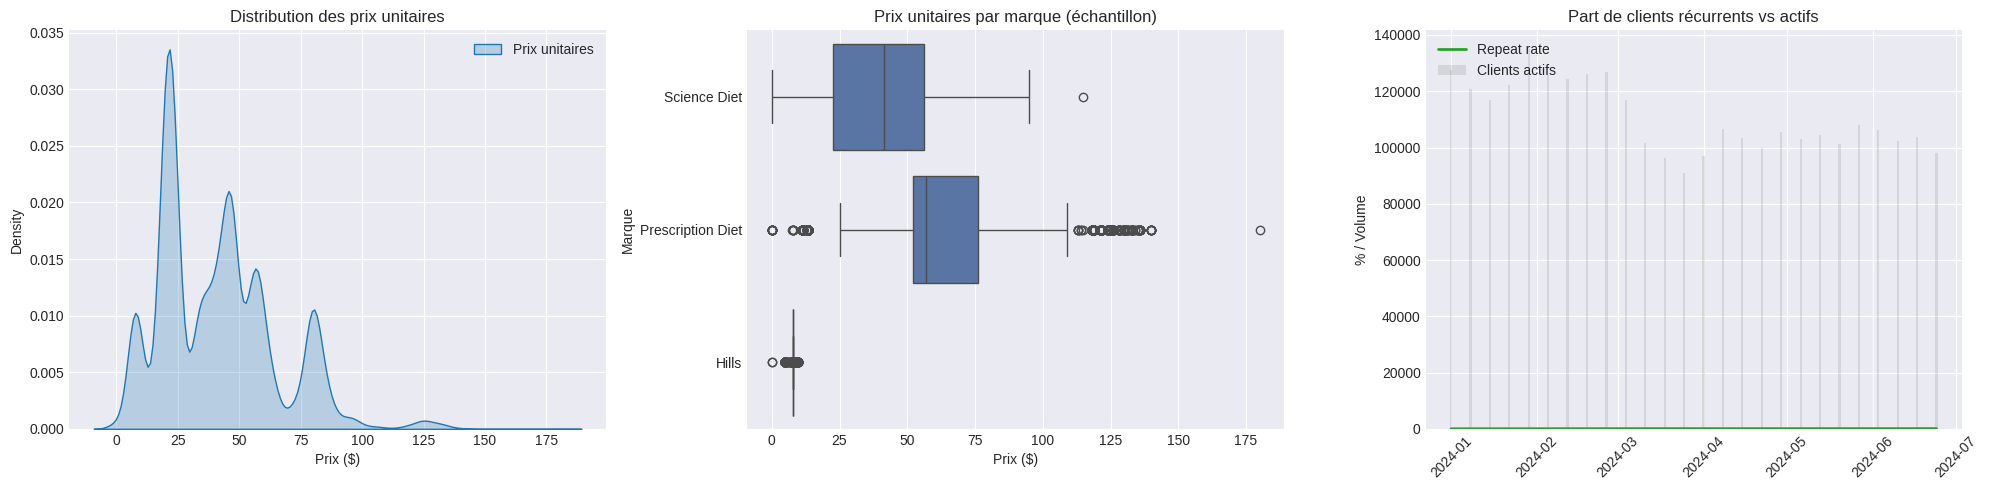

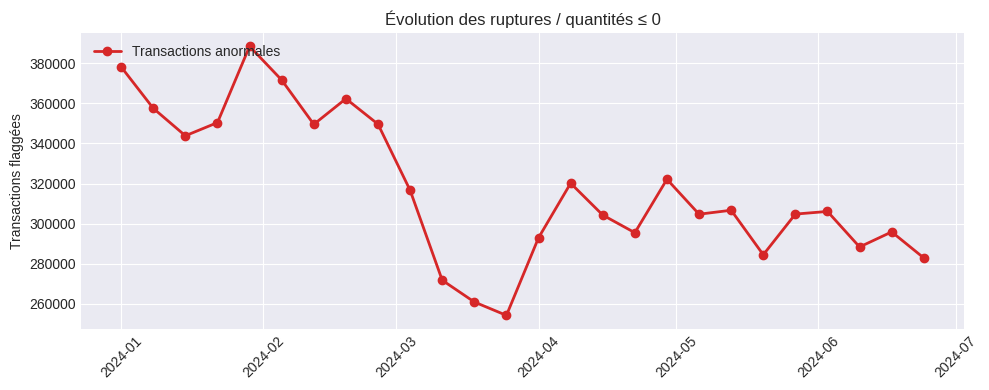

In [ ]:
# Retailer price & frequency insights
price_sample = (
    retailer
    .select(["unit_price", "brand", "sales"])
    .drop_nulls("unit_price")
    .sample(fraction=0.02, with_replacement=False, shuffle=True)
    .to_pandas()
)

crm_first_week = (
    customer_lifecycle
    .select([
        pl.col("customer_id"),
        pl.col("first_purchase").dt.truncate("1w").alias("first_week")
    ])
)

weekly_repeat = (
    retailer_lazy
    .select(["customer_id", "week_start"])
    .unique()
    .join(crm_first_week, on="customer_id", how="left")
    .with_columns(
        (pl.col("week_start") > pl.col("first_week")).alias("is_repeat")
    )
    .group_by("week_start")
    .agg([
        pl.len().alias("active_customers"),
        pl.sum("is_repeat").alias("repeat_customers"),
    ])
    .with_columns(
        (pl.col("repeat_customers") / pl.col("active_customers")).alias("repeat_rate"),
    )
    .sort("week_start")
    .collect()
    .to_pandas()
)

stock_timeline = (
    retailer_lazy
    .filter(pl.col("quantity") <= 0)
    .group_by("week_start")
    .agg(pl.len().alias("anomaly_tx"))
    .sort("week_start")
    .collect()
    .to_pandas()
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.kdeplot(data=price_sample, x="unit_price", fill=True, ax=axes[0], color="tab:blue", label="Prix unitaires")
axes[0].set_title("Distribution des prix unitaires")
axes[0].set_xlabel("Prix ($)")
axes[0].legend(loc="upper right")

sns.boxplot(data=price_sample, y="brand", x="unit_price", ax=axes[1], orient="h")
axes[1].set_title("Prix unitaires par marque (échantillon)")
axes[1].set_xlabel("Prix ($)")
axes[1].set_ylabel("Marque")

axes[2].plot(weekly_repeat["week_start"], weekly_repeat["repeat_rate"] * 100, label="Repeat rate", color="tab:green", linewidth=2)
axes[2].bar(weekly_repeat["week_start"], weekly_repeat["active_customers"], alpha=0.2, color="tab:gray", label="Clients actifs")
axes[2].set_title("Part de clients récurrents vs actifs")
axes[2].set_ylabel("% / Volume")
axes[2].tick_params(axis='x', rotation=45)
handles1, labels1 = axes[2].get_legend_handles_labels()
axes[2].legend(handles1, labels1, loc="upper left")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(stock_timeline["week_start"], stock_timeline["anomaly_tx"], color="tab:red", linewidth=2, marker="o", label="Transactions anormales")
plt.title("Évolution des ruptures / quantités ≤ 0")
plt.ylabel("Transactions flaggées")
plt.xticks(rotation=45)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


## Données Hill's – Segments CRM & Produits

Objectifs couverts:
- **Segments CRM**: catégoriser les clients (New / Repeat / Loyal, High vs Mid vs Low value).
- **Produits**: visualiser la répartition Prescription Diet, Science Diet, autres gammes.
- **Feedback clients**: identifier les champs manquants dans les données fournies.


In [ ]:
# Hill's CRM & product segments
retailer_lazy = (
    sc_retailer
    .with_columns([
        pl.col("timestamp_utc").str.strptime(pl.Datetime, strict=False, format=None).alias("ts"),
        pl.col("sales").fill_null(0),
        pl.col("quantity").fill_null(0),
    ])
    .with_columns([
        pl.col("ts").dt.date().alias("order_date"),
        pl.col("ts").dt.truncate("1w").alias("week_start"),
        pl.col("ts").dt.truncate("1mo").alias("month_start"),
        pl.when(pl.col("quantity") <= 0)
          .then(None)
          .otherwise(pl.col("sales") / pl.col("quantity"))
          .alias("unit_price"),
    ])
)

hill_products = (
    retailer_lazy
    .with_columns([
        pl.when(pl.col("brand").str.to_lowercase().str.contains("prescription"))
          .then("Prescription Diet")
          .when(pl.col("brand").str.to_lowercase().str.contains("science"))
          .then("Science Diet")
          .otherwise(pl.coalesce([pl.col("brand"), pl.lit("Autres")]))
          .alias("product_segment"),
        pl.coalesce([pl.col("product_name"), pl.lit("Produit inconnu")]).alias("product_name_clean"),
    ])
)

product_summary = (
    hill_products
    .group_by("product_segment")
    .agg([
        pl.col("sales").sum().alias("sales"),
        pl.col("customer_id").n_unique().alias("customers"),
        pl.len().alias("transactions"),
    ])
    .with_columns((pl.col("sales") / pl.col("customers")).alias("sales_per_customer"))
    .sort("sales", descending=True)
    .collect()
)

customer_lifecycle = (
    retailer_lazy
    .group_by("customer_id")
    .agg([
        pl.len().alias("transactions"),
        pl.col("sales").sum().alias("sales"),
        pl.col("ts").min().alias("first_purchase"),
        pl.col("ts").max().alias("last_purchase"),
    ])
    .with_columns([
        (pl.col("last_purchase") - pl.col("first_purchase")).dt.total_days().alias("lifetime_days"),
    ])
    .collect()
)

customer_crm = (
    customer_lifecycle
    .with_columns([
        pl.when(pl.col("transactions") >= 5).then("Loyal")
          .when(pl.col("transactions") >= 2).then("Repeat")
          .otherwise("New").alias("crm_tx"),
        pl.when(pl.col("sales") >= 300).then("High value")
          .when(pl.col("sales") >= 100).then("Mid value")
          .otherwise("Low value").alias("crm_value"),
    ])
    .with_columns(
        pl.concat_str([pl.col("crm_tx"), pl.lit(" / "), pl.col("crm_value")]).alias("crm_segment")
    )
)

fav_segment = (
    hill_products
    .group_by(["customer_id", "product_segment"])
    .agg(pl.col("sales").sum().alias("segment_sales"))
    .group_by("customer_id")
    .agg(
        pl.col("product_segment").sort_by(pl.col("segment_sales"), descending=True).first().alias("top_segment")
    )
)

crm_product = (
    customer_crm
    .join(fav_segment, on="customer_id", how="left")
    .group_by(["crm_segment", "top_segment"])
    .agg(pl.len().alias("customers"))
    .sort(["crm_segment", "customers"], descending=[False, True])
    .collect()
)

crm_summary = (
    customer_crm
    .group_by("crm_segment")
    .agg([
        pl.len().alias("customers"),
        pl.col("sales").sum().alias("sales"),
    ])
    .sort("customers", descending=True)
    .collect()
)

feedback_gap = pl.DataFrame({
    "data_point": ["customer_feedback", "nps", "sentiment"],
    "status": ["missing"] * 3,
    "action": [
        "Aucun verbatim / note de satisfaction fourni",
        "Pas de champ NPS → prévoir import CRM",
        "Pas de signal qualitatif → envisager enquête",
    ],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(product_summary["product_segment"], product_summary["sales"], color="tab:purple")
axes[0].set_title("Chiffre d'affaires par segment produit")
axes[0].set_ylabel("Sales ($)")
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(["Sales totaux"], loc="upper right")

crm_plot = crm_summary.to_pandas()
axes[1].barh(crm_plot["crm_segment"], crm_plot["customers"], color="tab:blue")
axes[1].set_title("Distribution des segments CRM")
axes[1].set_xlabel("Clients")
axes[1].legend(["Clients"], loc="lower right")

plt.tight_layout()
plt.show()

crm_product_pivot = crm_product.pivot(
    values="customers",
    index="crm_segment",
    columns="top_segment",
)
plt.figure(figsize=(10, 6))
sns.heatmap(crm_product_pivot.fill_null(0).to_pandas(), annot=True, fmt=".0f", cmap="Blues")
plt.title("Segments CRM × Produits préférés")
plt.xlabel("Produit")
plt.ylabel("Segment CRM")
plt.tight_layout()
plt.show()

print("Feedback clients – champs manquants:")
print(feedback_gap)


ColumnNotFoundError: unable to find column "Prescription Diet"; valid columns: ["customer_id", "timestamp_utc", "event_name", "brand", "product_name", "sales", "quantity", "ts", "order_date", "week_start", "month_start", "unit_price"]

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
 WITH_COLUMNS:
 [col("ts").dt.date().alias("order_date"), col("ts").dt.truncate(["1w"]).alias("week_start"), col("ts").dt.truncate(["1mo"]).alias("month_start"), when([(col("quantity")) <= (0.0)]).then(null.cast(Float64)).otherwise([(col("sales")) / (col("quantity"))]).alias("unit_price")] 
   WITH_COLUMNS:
   [col("timestamp_utc").str.strptime(["raise"]).alias("ts"), col("sales").fill_null([0.0]), col("quantity").fill_null([0.0])] 
    FILTER col("customer_id").cast(String).str.strip_chars([null]).str.lowercase().is_in([["", "unknown", … "none"]]).not()
    FROM
      FILTER [(col("customer_id").cast(String).str.strip_chars([null]).str.len_chars()) > (0)]
      FROM
        FILTER col

## Heatmaps Ventes × Socio-Démo par Device

Objectif: visualiser le chiffre d'affaires généré (après jointure Retail × Socio-Demo × Publisher) selon les tranches d'âge et de revenu, ventilé par `device_type` programmatique/TV.


In [ ]:
# Heatmaps ventes par device type (standalone pipeline)
DATA_PATH = Path("input_data") / "X_2025"

INVALID_TOKENS = ("", "unknown", "unk", "na", "null", "none")

def clean(expr: pl.Expr) -> pl.Expr:
    return expr.cast(pl.Utf8, strict=False).str.strip_chars()

def valid(expr: pl.Expr, allow_unknown: bool = True) -> pl.Expr:
    lowered = clean(expr).str.to_lowercase()
    mask = lowered.is_in(INVALID_TOKENS)
    return clean(expr).is_not_null() & (clean(expr).str.len_chars() > 0) & (~mask | allow_unknown)

retailer_sales = (
    pl.scan_csv(DATA_PATH / "retailer.csv")
    .with_columns(clean(pl.col("customer_id")).alias("customer_id"))
    .filter(valid(pl.col("customer_id"), allow_unknown=False))
    .select([
        "customer_id",
        pl.col("sales").cast(pl.Float64, strict=False).fill_null(0),
    ])
    .group_by("customer_id")
    .agg(pl.col("sales").sum().alias("sales_value"))
)

mapping = (
    pl.scan_csv(DATA_PATH / "mapping_transac_publisher_tv.csv")
    .with_columns([
        clean(pl.col("customer_id")).alias("customer_id"),
        clean(pl.col("device_id")).alias("device_id"),
        clean(pl.col("dsp_id")).alias("dsp_id"),
    ])
    .filter(valid(pl.col("customer_id"), allow_unknown=False))
)

mapping_devices = mapping.select(["customer_id", "device_id"]).filter(valid(pl.col("device_id")))
mapping_dsp = mapping.select(["customer_id", "dsp_id"]).filter(valid(pl.col("dsp_id")))

tv_events = (
    pl.scan_csv(DATA_PATH / "tv_publisher.csv")
    .with_columns([
        clean(pl.col("device_id")).alias("device_id"),
        pl.col("timestamp_utc").str.strptime(pl.Datetime, strict=False),
        (pl.col("cost_milli_cent") / 100000).alias("spend_usd"),
    ])
    .filter(valid(pl.col("device_id")))
    .join(mapping_devices, on="device_id", how="inner")
    .select([
        pl.col("customer_id"),
        pl.lit("TV").alias("device_type"),
    ])
)

prog_events = (
    pl.scan_csv(DATA_PATH / "programmatic_publisher.csv")
    .with_columns([
        clean(pl.col("dsp_id")).alias("dsp_id"),
        pl.col("timestamp_utc").str.strptime(pl.Datetime, strict=False),
        pl.coalesce([pl.col("device_type"), pl.lit("Unknown device")]).alias("device_type"),
    ])
    .filter(valid(pl.col("dsp_id")))
    .join(mapping_dsp, on="dsp_id", how="inner")
    .select([
        pl.col("customer_id"),
        pl.col("device_type"),
    ])
)

publisher_events = pl.concat([tv_events, prog_events], how="vertical")

socio = (
    pl.scan_csv(DATA_PATH / "socio_demo.csv")
    .with_columns(clean(pl.col("customer_id")).alias("customer_id"))
    .filter(valid(pl.col("customer_id"), allow_unknown=False))
    .select(["customer_id", "age", "income"])
)

device_sales_heat = (
    publisher_events
    .join(retailer_sales, on="customer_id", how="left")
    .join(socio, on="customer_id", how="left")
    .filter(pl.col("age").is_not_null() & pl.col("income").is_not_null())
    .group_by(["device_type", "age", "income"])
    .agg(pl.col("sales_value").sum().alias("sales"))
    .sort("sales", descending=True)
    .collect()
)

device_sales_pd = device_sales_heat.to_pandas()
if device_sales_pd.empty:
    print("Aucune donnée socio-démo disponible après jointure Retail × Publisher × Socio.")
else:
    device_types = device_sales_pd["device_type"].unique()
    fig, axes = plt.subplots(1, len(device_types), figsize=(6 * len(device_types), 5))
    if len(device_types) == 1:
        axes = [axes]
    for ax, device in zip(axes, device_types):
        subset = device_sales_pd[device_sales_pd["device_type"] == device]
        pivot = subset.pivot_table(index="income", columns="age", values="sales", aggfunc="sum", fill_value=0)
        if pivot.size == 0:
            ax.text(0.5, 0.5, f"Pas de ventes pour {device}", ha='center')
            ax.axis('off')
            continue
        sns.heatmap(pivot, ax=ax, cmap="flare", cbar_kws={"label": "Ventes ($)"})
        ax.set_title(f"Ventes par segment socio – {device}")
        ax.set_xlabel("Age")
        ax.set_ylabel("Income")
    plt.suptitle("Heatmaps Ventes × Age × Income par device type")
    plt.tight_layout()
    plt.show()



## 2. Données Publishers (Impressions, Ordre d'exposition, Interactions)

Composants couverts :
- **TV & Programmatique** : conversion des `cost_milli_cent` en dollars, comptage des impressions, CPM et reach.
- **Ordre d'exposition** : séquences chronologiques par `customer_id` (via mapping device/dsp → client).
- **Interactions** : pas de colonnes `clicks` / `watch_time` dans les CSV fournis → la cellule produit un drapeau `data_gap` pour ces métriques.
- **Enrichissement socio-démo** : jonction avec `socio_demo` pour savoir quels segments reçoivent quelles expositions.


In [ ]:
# Préparation Publishers
mapping_devices = sc_mapping.select(["customer_id", "device_id"]).filter(pl.col("device_id").is_not_null())
mapping_dsp = sc_mapping.select(["customer_id", "dsp_id"]).filter(pl.col("dsp_id").is_not_null())

common_projection = ["customer_id", "touchpoint_id", "timestamp", "spend_usd", "channel"]

tv_events = (
    sc_tv
    .with_columns([
        pl.col("timestamp_utc").str.strptime(pl.Datetime, strict=False).alias("timestamp"),
        (pl.col("cost_milli_cent") / 100000).alias("spend_usd"),
    ])
    .join(mapping_devices, on="device_id", how="inner")
    .select([
        pl.col("customer_id"),
        pl.col("device_id").alias("touchpoint_id"),
        pl.col("timestamp"),
        pl.col("spend_usd"),
        pl.lit("TV").alias("channel"),
    ])
)

prog_events = (
    sc_prog
    .with_columns([
        pl.col("timestamp_utc").str.strptime(pl.Datetime, strict=False).alias("timestamp"),
        (pl.col("cost_milli_cent") / 100000).alias("spend_usd"),
    ])
    .join(mapping_dsp, on="dsp_id", how="inner")
    .select([
        pl.col("customer_id"),
        pl.col("dsp_id").alias("touchpoint_id"),
        pl.col("timestamp"),
        pl.col("spend_usd"),
        pl.lit("Programmatic").alias("channel"),
    ])
)

publisher_events = pl.concat([tv_events, prog_events], how="vertical")

publisher_kpis = (
    publisher_events
    .group_by("channel")
    .agg([
        pl.len().alias("impressions"),
        pl.col("customer_id").n_unique().alias("unique_customers"),
        pl.col("spend_usd").sum().alias("spend_usd"),
        (pl.col("spend_usd").sum() / pl.len() * 1000).alias("cpm"),
    ])
    .collect()
)

sequence_sample = (
    publisher_events
    .sort(["customer_id", "timestamp"])
    .group_by("customer_id")
    .agg([
        pl.len().alias("touchpoints"),
        pl.col("channel").alias("channel_sequence"),
        pl.col("timestamp").alias("timestamps"),
    ])
    .filter(pl.col("touchpoints") >= 3)
    .limit(5)
    .collect()
)

publisher_socio = (
    publisher_events
    .join(sc_socio, on="customer_id", how="left")
    .group_by(["channel", "age", "income"])
    .agg([
        pl.col("customer_id").n_unique().alias("unique_customers"),
        pl.len().alias("impressions"),
    ])
    .sort("impressions", descending=True)
    .head(20)
    .collect()
)

publisher_gaps = pl.DataFrame({
    "metric": ["clicks", "watch_time"],
    "status": ["missing", "missing"],
    "comment": [
        "Aucune colonne de clics fournie → prévoir pixel ou log ad-server.",
        "Pas de données watch_time → nécessaire pour la vidéo.",
    ],
})

print("KPIs publishers :")
print(publisher_kpis)
print("\nSéquences d'exposition (échantillon) :")
print(sequence_sample)
print("\nRépartition socio-démo des expositions (top 20 combinaisons) :")
print(publisher_socio)
print("\nDonnées manquantes côté interactions :")
print(publisher_gaps)


KPIs publishers :
shape: (2, 5)
┌──────────────┬─────────────┬──────────────────┬───────────────┬───────────┐
│ channel      ┆ impressions ┆ unique_customers ┆ spend_usd     ┆ cpm       │
│ ---          ┆ ---         ┆ ---              ┆ ---           ┆ ---       │
│ str          ┆ u32         ┆ u32              ┆ f64           ┆ f64       │
╞══════════════╪═════════════╪══════════════════╪═══════════════╪═══════════╡
│ Programmatic ┆ 15275432    ┆ 4999660          ┆ 81176.087668  ┆ 5.31416   │
│ TV           ┆ 5540910     ┆ 2024362          ┆ 128854.461081 ┆ 23.255108 │
└──────────────┴─────────────┴──────────────────┴───────────────┴───────────┘

Séquences d'exposition (échantillon) :
shape: (5, 4)
┌────────────────────┬─────────────┬──────────────────────┬─────────────────────────────────┐
│ customer_id        ┆ touchpoints ┆ channel_sequence     ┆ timestamps                      │
│ ---                ┆ ---         ┆ ---                  ┆ ---                             │
│ str   